<a href="https://colab.research.google.com/github/gp4u99/python-portfolio-projects-/blob/main/Copy_of_My__python_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# 1. Create a market dataset using Pandas & NumPy
data = {
    'Asset': ['AUD/USD', 'XAG/USD', 'USOIL', 'XAU/USD', 'USD/JPY'],
    'Price': [0.6720, 29.80, 71.50, 2500.10, 142.30],
    'Daily_Change_%': [-0.25, 1.15, 0.40, 0.85, -0.60],
    'Volume_M': [120, 85, 210, 340, 190]
}

# 2. Load into a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Perform data analytics using NumPy operations
df['Price_Moving_Avg'] = df['Price'] * 0.985  # Simulated 20-period moving average
avg_volume = np.mean(df['Volume_M'])
top_gainers = df[df['Daily_Change_%'] > 0]

# 4. Display output report
print("=== FINANCIAL MARKET DATASET ===")
print(df)
print("\n=== MARKET SUMMARY ===")
print(f"Average Daily Volume: {avg_volume:.2f}M")
print(f"Total Bullish Assets: {len(top_gainers)}")


=== FINANCIAL MARKET DATASET ===
     Asset     Price  Daily_Change_%  Volume_M  Price_Moving_Avg
0  AUD/USD     0.672           -0.25       120           0.66192
1  XAG/USD    29.800            1.15        85          29.35300
2    USOIL    71.500            0.40       210          70.42750
3  XAU/USD  2500.100            0.85       340        2462.59850
4  USD/JPY   142.300           -0.60       190         140.16550

=== MARKET SUMMARY ===
Average Daily Volume: 189.00M
Total Bullish Assets: 3


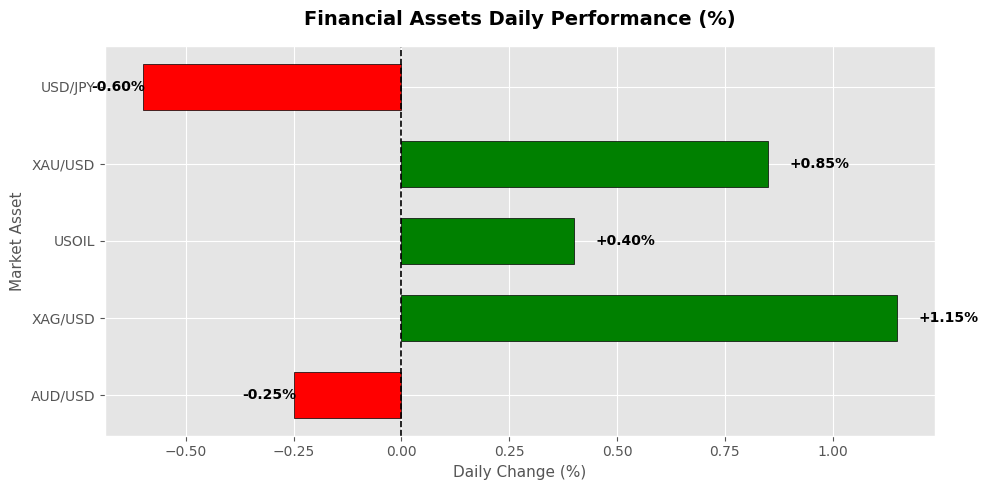

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Re-create market dataset
data = {
    'Asset': ['AUD/USD', 'XAG/USD', 'USOIL', 'XAU/USD', 'USD/JPY'],
    'Daily_Change_%': [-0.25, 1.15, 0.40, 0.85, -0.60],
    'Volume_M': [120, 85, 210, 340, 190]
}
df = pd.DataFrame(data)

# 2. Set up visual style
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Color bars dynamically (Green for Bullish / Red for Bearish)
colors = ['green' if x > 0 else 'red' for x in df['Daily_Change_%']]

# 4. Create Horizontal Bar Chart
bars = ax.barh(df['Asset'], df['Daily_Change_%'], color=colors, edgecolor='black', height=0.6)

# 5. Formatting & Labels
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')  # Zero performance line
ax.set_title('Financial Assets Daily Performance (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Daily Change (%)', fontsize=11)
ax.set_ylabel('Market Asset', fontsize=11)

# Add values on the end of each bar
for bar in bars:
    width = bar.get_width()
    offset = 0.05 if width >= 0 else -0.12
    ax.text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:+.2f}%",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Fetching live market data from Yahoo Finance API...



/tmp/ipykernel_1408/3858883907.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='1mo', interval='1d')['Close']
[*********************100%***********************]  3 of 3 completed


       LIVE MARKET CLOSING PRICES          
AUDUSD=X  : $0.7115
CL=F      : $100.3000
GC=F      : $4424.8999


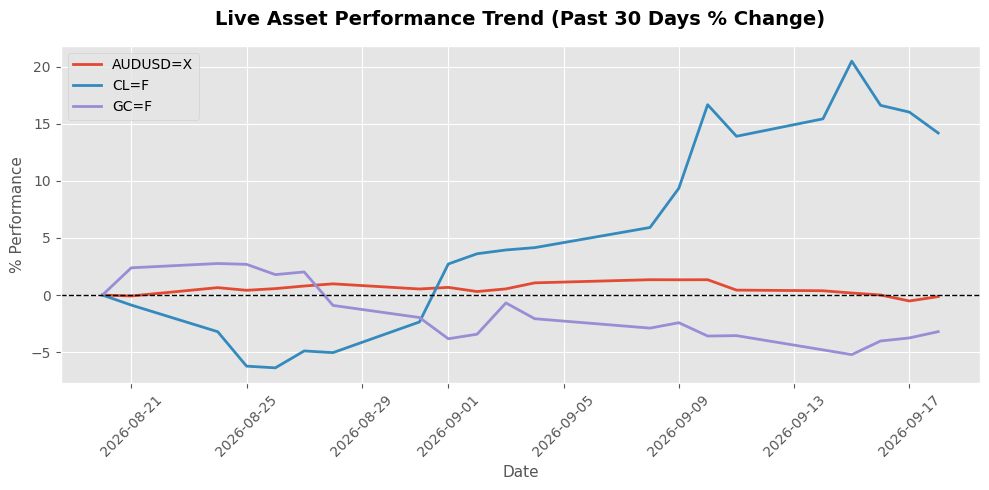

In [3]:
# 1. Install Yahoo Finance API package
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 2. Define Live Financial Tickers
tickers = ['GC=F', 'CL=F', 'AUDUSD=X']

print("Fetching live market data from Yahoo Finance API...\n")

# 3. Download data (period='1mo' fetches 1 month of daily data)
data = yf.download(tickers, period='1mo', interval='1d')['Close']

# Drop any missing values to prevent index errors
data = data.dropna()

# Check if data was successfully fetched
if not data.empty:
    # Display latest live prices
    latest_prices = data.iloc[-1]
    print("==========================================")
    print("       LIVE MARKET CLOSING PRICES          ")
    print("==========================================")
    for ticker, price in latest_prices.items():
        print(f"{ticker:<10}: ${price:.4f}")
    print("==========================================")

    # 4. Plot Live Price History
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(10, 5))

    # Normalize data to percentage change from start of month
    normalized_data = (data / data.iloc[0] - 1) * 100

    for column in normalized_data.columns:
        ax.plot(normalized_data.index, normalized_data[column], label=column, linewidth=2)

    ax.set_title('Live Asset Performance Trend (Past 30 Days % Change)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('% Performance', fontsize=11)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.legend(loc='upper left')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No data retrieved. Please check your internet connection and try running again.")


Fetching 6 months of historical daily data for GC=F...



/tmp/ipykernel_1408/2124252383.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='6mo', interval='1d')[['Close']].dropna()
[*********************100%***********************]  1 of 1 completed


     ALGORITHMIC SIGNAL REPORT: GC=F
Latest Price  : $4424.90
10-Day SMA    : $4408.93
30-Day SMA    : $4481.28
Current Signal: BEARISH (SELL)


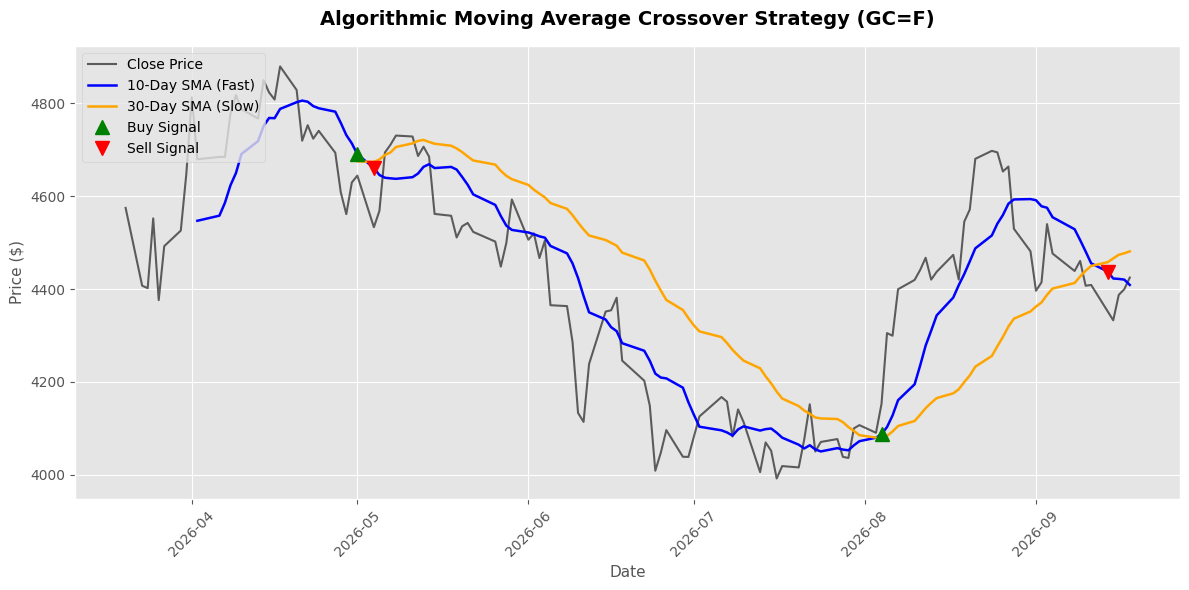

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Fetch historical data for Gold Futures (GC=F)
symbol = 'GC=F'
print(f"Fetching 6 months of historical daily data for {symbol}...\n")
df = yf.download(symbol, period='6mo', interval='1d')[['Close']].dropna()

# Clean multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Calculate Fast (10-day) and Slow (30-day) Simple Moving Averages (SMA)
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_30'] = df['Close'].rolling(window=30).mean()

# 3. Generate Trading Signals (1 = Bullish Crossover / Buy, -1 = Bearish Crossover / Sell)
df['Signal'] = 0
df['Signal'] = np.where(df['SMA_10'] > df['SMA_30'], 1, -1)

# Identify exact crossover points
df['Position_Change'] = df['Signal'].diff()

# 4. Display recent market signal
latest_close = df['Close'].iloc[-1]
latest_sma10 = df['SMA_10'].iloc[-1]
latest_sma30 = df['SMA_30'].iloc[-1]
latest_signal = "BULLISH (BUY)" if df['Signal'].iloc[-1] == 1 else "BEARISH (SELL)"

print("==========================================")
print(f"     ALGORITHMIC SIGNAL REPORT: {symbol}")
print("==========================================")
print(f"Latest Price  : ${latest_close:.2f}")
print(f"10-Day SMA    : ${latest_sma10:.2f}")
print(f"30-Day SMA    : ${latest_sma30:.2f}")
print(f"Current Signal: {latest_signal}")
print("==========================================")

# 5. Plot Price with Moving Averages and Buy/Sell Signals
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6, linewidth=1.5)
ax.plot(df.index, df['SMA_10'], label='10-Day SMA (Fast)', color='blue', linewidth=1.8)
ax.plot(df.index, df['SMA_30'], label='30-Day SMA (Slow)', color='orange', linewidth=1.8)

# Plot Buy Signals (Green Triangles)
ax.plot(df[df['Position_Change'] == 2].index,
        df['SMA_10'][df['Position_Change'] == 2],
        '^', markersize=10, color='green', label='Buy Signal', lw=0)

# Plot Sell Signals (Red Triangles)
ax.plot(df[df['Position_Change'] == -2].index,
        df['SMA_10'][df['Position_Change'] == -2],
        'v', markersize=10, color='red', label='Sell Signal', lw=0)

ax.set_title(f'Algorithmic Moving Average Crossover Strategy ({symbol})', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price ($)', fontsize=11)
ax.legend(loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
